# Random Forest

In [16]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000  # Use None for full dataset training.

if not DATA_FILE.exists():
    raise FileNotFoundError("Run src/01_process_data.py first to create cleaned_transactions.csv")

## Load Cleaned Data

In [17]:
use_columns = [
    "id", "date", "amount", "use_chip", "merchant_state", "mcc", "errors", "is_fraud"
]

transactions = pd.read_csv(DATA_FILE, usecols=use_columns)
transactions.shape

(8914963, 8)

In [18]:
transactions["is_fraud"].value_counts(normalize=True).mul(100).round(4).rename("percent")

is_fraud
0    99.8505
1     0.1495
Name: percent, dtype: float64

## Feature Engineering

In [19]:
model_data = transactions.copy()

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data["amount_value"] = pd.to_numeric(
    model_data["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
model_data["abs_amount"] = model_data["amount_value"].abs()
model_data["is_negative_amount"] = (model_data["amount_value"] < 0).astype(int)
model_data["hour"] = model_data["date"].dt.hour
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["month"] = model_data["date"].dt.month
model_data["has_error"] = model_data["errors"].notna().astype(int)

feature_columns = [
    "abs_amount",
    "is_negative_amount",
    "hour",
    "day_of_week",
    "month",
    "use_chip",
    "merchant_state",
    "mcc",
    "has_error",
]

X = model_data[feature_columns]
y = model_data["is_fraud"].astype(int)

pd.DataFrame({"feature": feature_columns})

,feature
0,abs_amount
1,is_negative_amount
2,hour
3,day_of_week
4,month
5,use_chip
6,merchant_state
7,mcc
8,has_error


## Optional Stratified Sampling

In [20]:
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X):
    _, X_model, _, y_model = train_test_split(
        X,
        y,
        test_size=SAMPLE_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
else:
    X_model = X
    y_model = y

sample_summary = pd.DataFrame(
    {
        "label": ["Non-fraud", "Fraud"],
        "rows": [int((y_model == 0).sum()), int((y_model == 1).sum())],
        "percent": [round((y_model == 0).mean() * 100, 4), round((y_model == 1).mean() * 100, 4)],
    }
)
sample_summary

,label,rows,percent
0,Non-fraud,499252,99.8504
1,Fraud,748,0.1496


## Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.25,
    stratify=y_model,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "fraud rows": [int(y_train.sum()), int(y_test.sum())],
        "fraud rate (%)": [round(y_train.mean() * 100, 4), round(y_test.mean() * 100, 4)],
    }
)
split_summary

,split,rows,fraud rows,fraud rate (%)
0,train,375000,561,0.1496
1,test,125000,187,0.1496


## Build Random Forest Pipeline

In [22]:
numeric_features = ["abs_amount", "is_negative_amount", "hour", "day_of_week", "month", "has_error"]
categorical_features = ["use_chip", "merchant_state", "mcc"]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=16,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_model),
    ]
)
rf_pipeline

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Train Model

In [23]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluate Model

In [24]:
y_pred = rf_pipeline.predict(X_test)
y_score = rf_pipeline.predict_proba(X_test)[:, 1]

metrics_summary = pd.DataFrame(
    {
        "metric": ["accuracy", "roc_auc", "pr_auc"],
        "value": [
            accuracy_score(y_test, y_pred),
            roc_auc_score(y_test, y_score),
            average_precision_score(y_test, y_score),
        ],
    }
)
metrics_summary.round(4)

,metric,value
0,accuracy,0.9418
1,roc_auc,0.9646
2,pr_auc,0.2657


In [25]:
print(classification_report(y_test, y_pred, target_names=["Non-fraud", "Fraud"], digits=4))

              precision    recall  f1-score   support

   Non-fraud     0.9998    0.9419    0.9700    124813
       Fraud     0.0226    0.8984    0.0442       187

    accuracy                         0.9418    125000
   macro avg     0.5112    0.9202    0.5071    125000
weighted avg     0.9984    0.9418    0.9686    125000



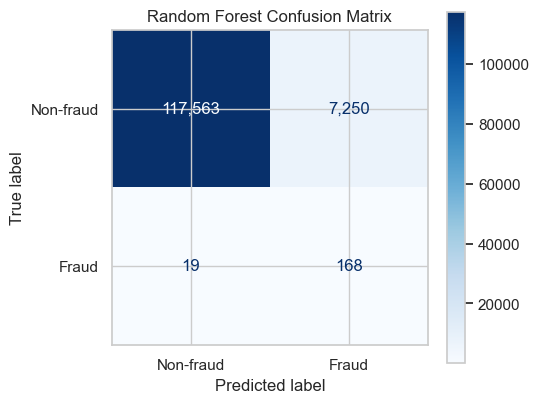

In [26]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-fraud", "Fraud"],
    cmap="Blues",
    values_format=",d",
    ax=ax,
)
ax.set_title("Random Forest Confusion Matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## Threshold Review

In [27]:
threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    threshold_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positives": fp,
            "false_negatives": fn,
        }
    )

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.round(4)

,threshold,precision,recall,f1,false_positives,false_negatives
0,0.1,0.0021,1.0000,0.0042,87883,0
1,0.2,0.0062,0.9465,0.0123,28359,10
2,0.3,0.0106,0.9198,0.0210,16012,15
3,0.4,0.0135,0.9091,0.0265,12454,17
4,0.5,0.0226,0.8984,0.0442,7250,19


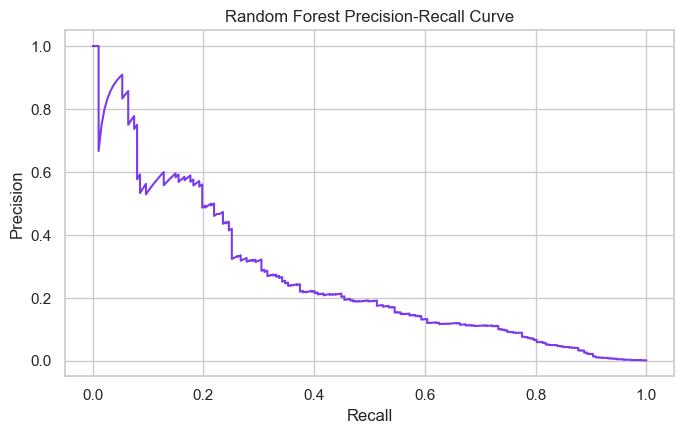

In [28]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color="#7c3aed")
ax.set_title("Random Forest Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## Feature Importance

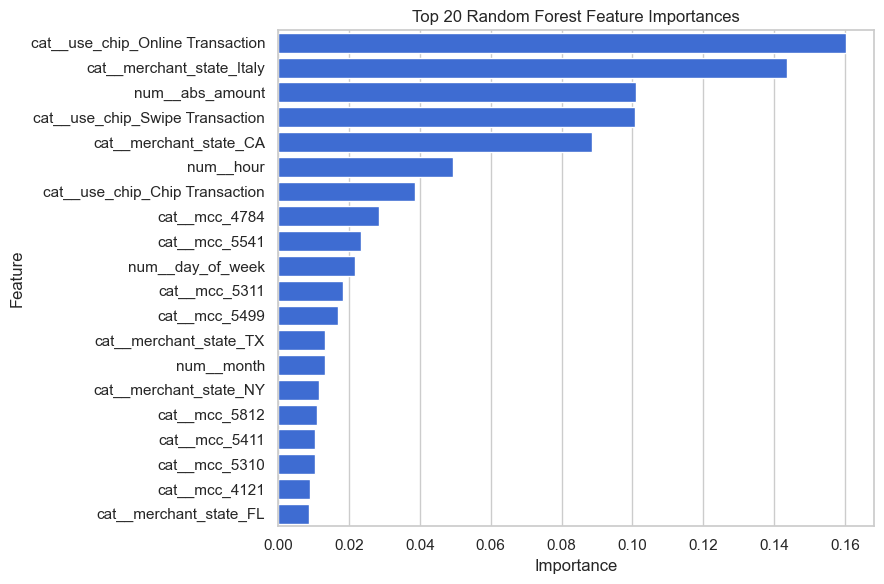

,feature,importance
7,cat__use_chip_Online Transaction,0.160209
61,cat__merchant_state_Italy,0.143561
0,num__abs_amount,0.101154
8,cat__use_chip_Swipe Transaction,0.100660
22,cat__merchant_state_CA,0.088714
2,num__hour,0.049405
6,cat__use_chip_Chip Transaction,0.038704
194,cat__mcc_4784,0.028555
212,cat__mcc_5541,0.023308
3,num__day_of_week,0.021766


In [29]:
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feature_importance, y="feature", x="importance", color="#2563eb", ax=ax)
ax.set_title("Top 20 Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_random_forest_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

feature_importance

## Save Model

In [30]:
model_path = MODEL_DIR / "random_forest_fraud_model.joblib"
joblib.dump(rf_pipeline, model_path)
model_path

PosixPath('/Users/zichen/Big-Data-Project/models/random_forest_fraud_model.joblib')